In [2]:
import functional_functions as ff
from nilearn.maskers import SurfaceLabelsMasker
from nilearn.connectome import ConnectivityMeasure, vec_to_sym_matrix, sym_matrix_to_vec
from nilearn.surface import SurfaceImage
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

/srv/conda/envs/notebook/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


# Get the Data

## Load the data from shared folder

In [21]:
home = Path.home()
data_win = Path(home) / "loss_training_corrmats_noDiag_072326.npy"
data_loss = data_ = Path(home) / "loss_training_corrmats_noDiag_072326.npy"
corr_mat_win = np.load(data_win)
corr_mat_loss = np.load(data_loss)

## Remove the first column of each array (subjects id)

In [23]:
corr_mat__win_ids = corr_mat_win[:, :1].astype(int)
corr_mat_win_no_id = corr_mat_win[:, 1:]

corr_mat__loss_ids = corr_mat_loss[:, :1].astype(int)
corr_mat_loss_no_id = corr_mat_loss[:, 1:]

corr_mat_win_no_id

array([[-0.04272356, -0.00297926,  0.880207  , ...,  0.93268935,
         0.60344308,  0.94355852],
       [ 0.54704642,  0.93583726,  0.54703601, ...,  0.6101892 ,
         0.94267891,  0.94839271],
       [ 0.15890188,  0.41878154,  0.79194025, ...,  0.9697324 ,
         0.82498838,  0.94494969],
       ...,
       [ 0.94462325, -0.20126691, -0.33539564, ...,  0.60624686,
        -0.59543962, -0.56596123],
       [-0.90718462, -0.84189767,  0.96676257, ..., -0.94869258,
        -0.82775205, -0.20636535],
       [ 0.94943628,  0.96197524,  0.94984199, ..., -0.74890077,
        -0.81763098,  0.85429512]])

# Prepare the data

## z-transform the matrices

In [24]:
corr_mat_win_zScore = np.arctanh(corr_mat_win_no_id)
corr_mat_loss_zScore = np.arctanh(corr_mat_loss_no_id)
np.shape(corr_mat_win_zScore)

(692, 64620)

## Load the sociodemographics

In [18]:
sociodem_df = pd.read_csv("train_split.csv")
delayed_discount_df = pd.read_csv("DD_AUC_targets.csv")

In [19]:
train_df = sociodem_df.merge(
    delayed_discount_df[["Subject", "DDisc_AUC_40K"]],
    on="Subject",
    how="left"
)

train_df = train_df[["Subject", "Gender", "Age", "DDisc_AUC_40K"]]
train_df

,Subject,Gender,Age,DDisc_AUC_40K
0,519647,M,26-30,0.100391
1,308129,M,22-25,0.831641
2,837560,M,26-30,0.227084
3,523032,M,31-35,0.885938
4,200614,F,31-35,0.499219
...,...,...,...,...
686,580650,F,31-35,0.080990
687,125525,F,31-35,0.555860
688,205725,F,22-25,0.804818
689,194746,M,31-35,0.870573


## Merge corr matraces with sociodemographics

In [43]:
# Bring corr_mat_ids and _zScores into dataframes
corr_mat_ids_df = pd.DataFrame(corr_mat_ids, columns=["Subject"])

corr_mat_zScore_df = pd.DataFrame(corr_mat_zScore)
corr_mat_zScore_df.columns = corr_mat_zScore_df.columns.astype(str)

# Add back the corr_mat labels


# merge them
corr_mat_zScore_id_df = corr_mat_ids_df.join(corr_mat_zScore_df)
corr_mat_zScore_id_df

,Subject,0,1,2,3,4,5,6,7,8,...,64970,64971,64972,64973,64974,64975,64976,64977,64978,64979
0,163129,0.881374,0.132101,0.881374,0.146091,1.603905,0.881374,1.110573,-0.130835,-0.131569,...,2.236028,-1.539670,-1.582493,1.709353,2.102953,1.578077,1.707525,0.639734,1.654159,0.881374
1,308129,0.881374,0.780898,0.881374,1.562151,0.669198,0.881374,2.479964,0.767234,1.678677,...,2.467078,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369,0.881374
2,529953,0.881374,0.151329,0.881374,0.520031,1.025373,0.881374,1.137482,-0.255290,0.174107,...,2.227548,1.500035,1.814953,1.744737,1.712765,2.356556,2.007970,1.253896,1.683845,0.881374
3,523032,0.881374,1.431399,0.881374,-0.368959,-0.616712,0.881374,1.549129,1.165729,-0.186658,...,1.886105,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245,0.881374
4,103818,0.881374,0.941414,0.881374,1.151969,0.797668,0.881374,0.736646,0.653387,0.730726,...,1.493517,1.369341,-0.642146,-0.070179,1.297456,-1.449586,1.257125,0.680511,1.318578,0.881374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,187547,0.881374,-0.053006,0.881374,0.549707,-0.038814,0.881374,1.489700,-0.205644,0.511159,...,0.043767,0.056428,0.080501,0.096474,0.051240,0.068160,0.012713,0.060017,0.143803,0.881374
688,978578,0.881374,0.863363,0.881374,-0.498795,-1.472985,0.881374,1.053940,0.277364,0.036701,...,-1.977177,-1.707319,-1.305074,-1.711601,-1.678103,-1.839434,2.154487,-1.514051,-1.504571,0.881374
689,205725,0.881374,1.627411,0.881374,-0.065188,-0.261277,0.881374,1.046754,0.654069,0.354225,...,-0.714799,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327,0.881374
690,185038,0.881374,-1.334677,0.881374,-1.048129,1.981017,0.881374,0.427200,0.039564,0.173465,...,2.108099,2.001780,-0.918754,-1.510568,-1.421983,1.369184,-2.023056,-1.318424,-0.405962,0.881374


In [44]:
merged_df = train_df.merge(
    corr_mat_zScore_id_df,
    on="Subject",
    how="left"
)
merged_df

,Subject,Gender,Age,DDisc_AUC_40K,0,1,2,3,4,5,...,64970,64971,64972,64973,64974,64975,64976,64977,64978,64979
0,519647,M,26-30,0.100391,0.881374,0.491604,0.881374,1.860610,0.446891,0.881374,...,2.156504,2.177905,1.315466,1.893233,2.191786,1.344485,1.990852,1.810121,2.255966,0.881374
1,308129,M,22-25,0.831641,0.881374,0.780898,0.881374,1.562151,0.669198,0.881374,...,2.467078,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369,0.881374
2,837560,M,26-30,0.227084,0.881374,-0.276561,0.881374,0.853873,-0.841922,0.881374,...,1.881538,1.867512,0.432121,0.412292,1.941996,-1.334595,1.869319,1.847818,1.920768,0.881374
3,523032,M,31-35,0.885938,0.881374,1.431399,0.881374,-0.368959,-0.616712,0.881374,...,1.886105,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245,0.881374
4,200614,F,31-35,0.499219,0.881374,-0.992230,0.881374,1.299904,-1.645951,0.881374,...,2.144932,1.941968,1.600177,1.564732,-1.762662,2.009018,1.999289,-1.219998,0.378260,0.881374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,580650,F,31-35,0.080990,0.881374,1.898847,0.881374,-1.049311,-1.070365,0.881374,...,-0.706797,-0.705389,-0.633959,-0.646141,-0.698717,-0.703320,0.711070,-0.707749,0.413009,0.881374
687,125525,F,31-35,0.555860,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
688,205725,F,22-25,0.804818,0.881374,1.627411,0.881374,-0.065188,-0.261277,0.881374,...,-0.714799,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327,0.881374
689,194746,M,31-35,0.870573,0.881374,0.798147,0.881374,0.768168,1.897988,0.881374,...,0.677774,0.736885,0.788292,0.528645,0.661937,0.610742,-0.627002,0.635853,0.890760,0.881374


# Analysis

## Define the predictors

In [30]:
demographic_vars = ['Gender', 'Age']
connectivity_vars = [str(i) for i in range(64620)]

## Transform ordinal data

In [47]:
age_ranges = merged_df["Age"].unique()
age_ranges

array(['26-30', '22-25', '31-35', '36+'], dtype=object)

In [46]:
age_mapping = {age: i for i, age in enumerate(age_ranges)}
merged_df["Age_ordinal"] = merged_df["Age"].map(age_mapping)
merged_df

,Subject,Gender,Age,DDisc_AUC_40K,0,1,2,3,4,5,...,64971,64972,64973,64974,64975,64976,64977,64978,64979,Age_ordinal
0,519647,M,26-30,0.100391,0.881374,0.491604,0.881374,1.860610,0.446891,0.881374,...,2.177905,1.315466,1.893233,2.191786,1.344485,1.990852,1.810121,2.255966,0.881374,0
1,308129,M,22-25,0.831641,0.881374,0.780898,0.881374,1.562151,0.669198,0.881374,...,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369,0.881374,1
2,837560,M,26-30,0.227084,0.881374,-0.276561,0.881374,0.853873,-0.841922,0.881374,...,1.867512,0.432121,0.412292,1.941996,-1.334595,1.869319,1.847818,1.920768,0.881374,0
3,523032,M,31-35,0.885938,0.881374,1.431399,0.881374,-0.368959,-0.616712,0.881374,...,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245,0.881374,2
4,200614,F,31-35,0.499219,0.881374,-0.992230,0.881374,1.299904,-1.645951,0.881374,...,1.941968,1.600177,1.564732,-1.762662,2.009018,1.999289,-1.219998,0.378260,0.881374,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,580650,F,31-35,0.080990,0.881374,1.898847,0.881374,-1.049311,-1.070365,0.881374,...,-0.705389,-0.633959,-0.646141,-0.698717,-0.703320,0.711070,-0.707749,0.413009,0.881374,2
687,125525,F,31-35,0.555860,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
688,205725,F,22-25,0.804818,0.881374,1.627411,0.881374,-0.065188,-0.261277,0.881374,...,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327,0.881374,1
689,194746,M,31-35,0.870573,0.881374,0.798147,0.881374,0.768168,1.897988,0.881374,...,0.736885,0.788292,0.528645,0.661937,0.610742,-0.627002,0.635853,0.890760,0.881374,2


In [48]:
# IMPORTANT: Do this after mapping and transforming the ordinal data, so that unmapped/unexpected strings in 
#            that step that became silently NaN are removed

# Clean
cleaned_df = merged_df.dropna(subset=connectivity_vars + ['Age_ordinal', 'Gender'])
cleaned_df = cleaned_df.copy() # Because otherwise numpy will complain later 'cause it doesn't know if it should also change the 'mother' train data
print(f"Usable training subjects: {len(cleaned_df)} out of {len(merged_df)}")

Usable training subjects: 657 out of 691


## Create dummy variables for categorical data

In [49]:
# Define categorical variables
categorical_cols = ['Gender']

# Dummy code
final_df = pd.get_dummies(
    cleaned_df,
    columns=categorical_cols,
    drop_first=True
)

final_df

,Subject,Age,DDisc_AUC_40K,0,1,2,3,4,5,6,...,64972,64973,64974,64975,64976,64977,64978,64979,Age_ordinal,Gender_M
0,519647,26-30,0.100391,0.881374,0.491604,0.881374,1.860610,0.446891,0.881374,2.337998,...,1.315466,1.893233,2.191786,1.344485,1.990852,1.810121,2.255966,0.881374,0,True
1,308129,22-25,0.831641,0.881374,0.780898,0.881374,1.562151,0.669198,0.881374,2.479964,...,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369,0.881374,1,True
2,837560,26-30,0.227084,0.881374,-0.276561,0.881374,0.853873,-0.841922,0.881374,1.272583,...,0.432121,0.412292,1.941996,-1.334595,1.869319,1.847818,1.920768,0.881374,0,True
3,523032,31-35,0.885938,0.881374,1.431399,0.881374,-0.368959,-0.616712,0.881374,1.549129,...,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245,0.881374,2,True
4,200614,31-35,0.499219,0.881374,-0.992230,0.881374,1.299904,-1.645951,0.881374,1.621055,...,1.600177,1.564732,-1.762662,2.009018,1.999289,-1.219998,0.378260,0.881374,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,415837,22-25,0.711719,0.881374,0.456525,0.881374,-1.034431,-0.170608,0.881374,2.029662,...,1.652966,1.445290,-0.992902,1.739485,-0.665040,1.720104,1.771391,0.881374,1,False
686,580650,31-35,0.080990,0.881374,1.898847,0.881374,-1.049311,-1.070365,0.881374,2.595453,...,-0.633959,-0.646141,-0.698717,-0.703320,0.711070,-0.707749,0.413009,0.881374,2,False
688,205725,22-25,0.804818,0.881374,1.627411,0.881374,-0.065188,-0.261277,0.881374,1.046754,...,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327,0.881374,1,False
689,194746,31-35,0.870573,0.881374,0.798147,0.881374,0.768168,1.897988,0.881374,1.620593,...,0.788292,0.528645,0.661937,0.610742,-0.627002,0.635853,0.890760,0.881374,2,True


## Elastic Net Pipeline

### Load sklearn modules

In [50]:
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

In [51]:
continuous_cols = ['Age_ordinal'] + connectivity_vars
feature_cols = ['Gender_M'] + continuous_cols

In [52]:
X = final_df[feature_cols]
y = final_df["DDisc_AUC_40K"]

## K-Fold Parameters

In [53]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# store out-of-fold predictions here — one prediction per subject
oof_predictions = np.full(len(X), np.nan)
fold_r2_scores = []

## Quickcheck the shape of the data

In [54]:
print(X.shape, y.shape)
print(X.index.equals(y.index))

(657, 64622) (657,)
True


# Run over folds

In [55]:
fold_coefs = []

for fold_num, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[continuous_cols] = scaler.fit_transform(X_tr[continuous_cols])
    X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

    # Tuning happens HERE, using only this fold's training data
    model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                          alphas=np.logspace(-3, 1, 50),
                          cv=5, random_state=42, max_iter=10000,
                        n_jobs=-1)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    oof_predictions[val_idx] = preds
    fold_r2_scores.append(model.score(X_val, y_val))
    print(f"Fold {fold_num + 1}: R² = {fold_r2_scores[-1]:.4f}, "
          f"alpha={model.alpha_:.4f}, l1_ratio={model.l1_ratio_}")
    fold_coefs.append(model.coef_)

print(f"Mean CV R²: {np.mean(fold_r2_scores):.4f} (+/- {np.std(fold_r2_scores):.4f})")

Fold 1: R² = 0.0181, alpha=0.4095, l1_ratio=0.1
Fold 2: R² = 0.0130, alpha=0.3393, l1_ratio=0.1
Fold 3: R² = 0.0193, alpha=0.4095, l1_ratio=0.1
Fold 4: R² = 0.0118, alpha=0.3393, l1_ratio=0.1
Fold 5: R² = 0.0626, alpha=0.0244, l1_ratio=1.0
Mean CV R²: 0.0250 (+/- 0.0191)


## Check overall out-of-fold correlation

In [56]:
from scipy.stats import pearsonr
r, p_val = pearsonr(y, oof_predictions)
print(f"Out-of-fold r = {r:.3f}, p = {p_val:.3f}")

Out-of-fold r = 0.165, p = 0.000


# Extract coefficient from the final model


In [57]:
fold_coef_df = pd.DataFrame(fold_coefs, columns=feature_cols)
print(fold_coef_df.describe())  # mean and std of each coefficient across folds

       Gender_M  Age_ordinal    0    1    2    3    4    5    6    7  ...  \
count       5.0          5.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  5.0  ...   
mean        0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
std         0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
min        -0.0         -0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
25%         0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
50%         0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
75%         0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
max        -0.0         -0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

       64610  64611  64612  64613  64614  64615  64616  64617  64618  64619  
count    5.0    5.0    5.0    5.0    5.0    5.0    5.0    5.0    5.0    5.0  
mean     0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
std      0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    

## Plot the results

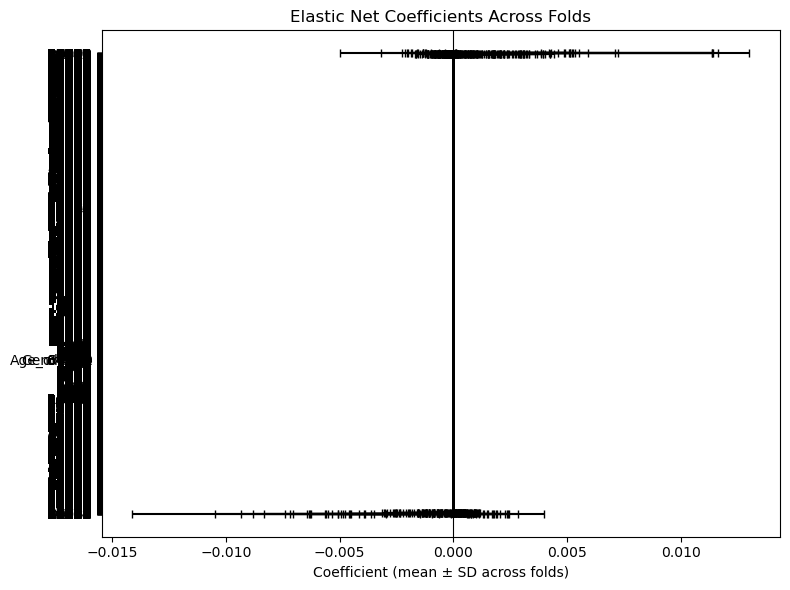

In [23]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Predicted vs actual, pooled out-of-fold
r, p = pearsonr(y, oof_predictions)
axes[0].scatter(y, oof_predictions, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_xlabel('Observed AUC_40K')
axes[0].set_ylabel('Predicted AUC_40K')
axes[0].set_title(f'Pooled OOF: r={r:.3f}, p={p:.4f}')

# (b) Fold-by-fold R²
axes[1].bar(range(1, len(fold_r2_scores)+1), fold_r2_scores)
axes[1].axhline(np.mean(fold_r2_scores), color='r', linestyle='--')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].set_title('CV performance by fold')

# (c) Coefficient stability: how many folds selected each edge as nonzero
nonzero_counts = (np.array(fold_coefs) != 0).sum(axis=0)
axes[2].hist(nonzero_counts, bins=6)
axes[2].set_xlabel('# folds edge was nonzero (out of 5)')
axes[2].set_title('Feature selection stability')

plt.tight_layout()
plt.show()

## Fit the final model

In [1]:
final_scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = final_scaler.fit_transform(X[continuous_cols])

final_model = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
    alphas=np.logspace(-3, 1, 50),
    cv=5,
    random_state=42,
    max_iter=10000,
    n_jobs=-1
)

final_model.fit(X_scaled, y)

print(f"Final alpha: {final_model.alpha_:.4f}")
print(f"Final l1_ratio: {final_model.l1_ratio_}")

NameError: name 'StandardScaler' is not defined

## Save the data

In [ ]:
python
import joblib

results = {
    'oof_predictions': oof_predictions,
    'y_true': y.values,
    'fold_r2_scores': fold_r2_scores,
    'fold_coefs': np.array(fold_coefs),        # shape: (n_folds, n_features)
    'final_coefs': final_model.coef_,
    'final_alpha': final_model.alpha_,
    'final_l1_ratio': final_model.l1_ratio_,
    'feature_cols': feature_cols,
    'final_scaler': final_scaler,
}

joblib.dump(results, 'elasticnet_ddisc_results.pkl')